In [ ]:
import os
import time
from rtm_pymmcore.core.data_structures import Channel, SegmentationMethod
from pprint import pprint
import pandas as pd
import rtm_pymmcore.core.utils as utils

# Minimal example
Using the default uManager demo devices, how to set up an experiment with rtm-pymmcore

## Connect to a microscope
Choose **one** of the two cells below:
- **Option A** – remote simulation via pymmcore-proxy
- **Option B** – local simulation via UniMMCoreSimulation

### Option A: Remote simulation (pymmcore-proxy)
Start the server first:
```
cd ~/sync/phd/code/self-learning/virtual-env && python scripts/serve_challenge.py challenge_404_volvox_phototaxis --no-challenge --port 5610
```

In [ ]:
from rtm_pymmcore.microscope.proxy import PymmcoreProxyMic
mic = PymmcoreProxyMic(url="http://127.0.0.1:5610")

### Option B: Local simulation (UniMMCoreSimulation)

## Start a simulation locally

In [ ]:
import sys
from rtm_pymmcore.microscope.simulation import UniMMCoreSimulation
sys.path.insert(0, "/Users/luhin/sync/phd/code/self-learning/virtual-env/src")
sys.path.insert(0, "/Users/luhin/sync/phd/code/self-learning/virtual-env/scenarios")

from challenge_404_volvox_phototaxis import generate

sim_out = generate()
mmc = sim_out[-1]
mic = UniMMCoreSimulation(mmc=mmc)

## Set up the processing and stimulation pipeline

In [ ]:
from rtm_pymmcore.segmentation.base import OtsuSegmentator
from rtm_pymmcore.stimulation.center_circle import CenterCircle
from rtm_pymmcore.tracking.trackpy import TrackerTrackpy
from rtm_pymmcore.feature_extraction.simple import SimpleFE
from rtm_pymmcore.core.pipeline import ImageProcessingPipeline


## Storage path for the experiment
base_path = "/tmp/"
experiment_name = "test-experiment"
path = os.path.join(base_path, experiment_name)


stimulator = CenterCircle()
feature_extractor = SimpleFE("labels")
tracker = TrackerTrackpy()
seg = OtsuSegmentator()

segmentators = [
    SegmentationMethod(
        name="labels",
        segmentation_class=OtsuSegmentator(),
        use_channel=0,
        save_tracked=True,
    )
]

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=segmentators,
    feature_extractor=feature_extractor,
    tracker=tracker,
    stimulator=stimulator,
)
mic.set_pipeline(pipeline=pipeline)

Preview the image segmentation and stimulation logic

In [4]:
utils.print_configs(mic.mmc)

Config Groups
└── Fake
    ├── brightfield
    ├── membrane-channel
    └── nucleus-channel

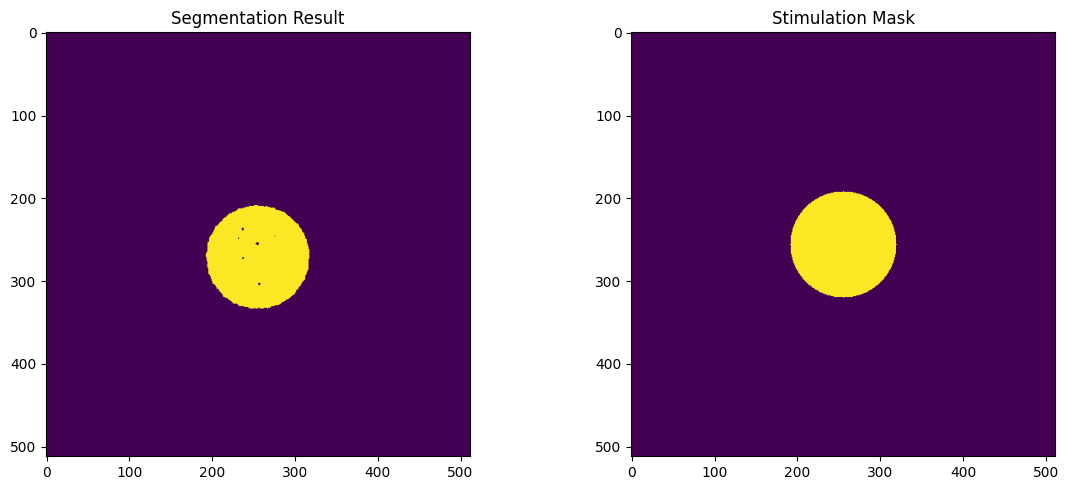

In [9]:
import matplotlib.pyplot as plt
import tifffile

mic.mmc.setConfig("Fake", "brightfield")
mic.mmc.setConfig("Fake", "nucleus-channel")
mic.mmc.snapImage()
test_img = mic.mmc.getImage()
res = seg.segment(test_img)
mask,_ = stimulator.get_stim_mask(label_images={"labels": res}, metadata={})


fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(res)
axes[0].set_title('Segmentation Result')
axes[1].imshow(mask)
axes[1].set_title('Stimulation Mask')
plt.tight_layout()



### GUI - Napari Micromanager with remote mmcore

In [6]:
import napari
import pymmcore_plus.core._mmcore_plus as _core_mod
from pymmcore_proxy import RemoteMMCore
from qtpy.QtCore import QObject, Signal as QtSignal, Slot
from napari_micromanager import MainWindow

# --- Marshal WebSocket signals onto Qt main thread ---
class _MainThreadRelay(QObject):
    _sig = QtSignal(object)
    def __init__(self, dispatch_fn):
        super().__init__()
        self._fn = dispatch_fn
        self._sig.connect(self._handle)
    @Slot(object)
    def _handle(self, msg):
        self._fn(msg)

_relay = _MainThreadRelay(mic.mmc._dispatch_signal)
mic.mmc._dispatch_signal = _relay._sig.emit
mic.mmc._relay = _relay  # prevent GC

#mic.mmc._start_signal_listener()

# --- Inject as singleton before MainWindow reads it ---
_core_mod._instance = mic.mmc

# --- Build GUI ---
viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
viewer.window.add_dock_widget(mm_wdg, name="MicroManager", area="top")

### GUI - Napari micromanager with local UniMMCore Simulation

In [10]:
import napari
import pymmcore_plus.core._mmcore_plus as _core_mod
from napari_micromanager import MainWindow

# Local CMMCorePlus emits psygnal signals directly from the MDA runner
# thread.  napari-micromanager handlers use @ensure_main_thread to
# marshal to Qt, so no relay is needed (unlike the proxy path).

# --- Inject as singleton before MainWindow reads it ---
_core_mod._instance = mic.mmc

# --- Build GUI ---
viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
viewer.window.add_dock_widget(mm_wdg, name="MicroManager", area="top")

In [7]:
mic.calibrate_dmd()

# Manually select FOVs
Open up MDA-acquisition in napari-micromanager, store a few positions, then load them in to the notebook

In [8]:
try:
    data_mda_fovs = viewer.window._dock_widgets["MDA"].widget().value().stage_positions
    data_mda_fovs_dict = []
    for data_mda in data_mda_fovs:
        data_mda_fovs_dict.append(data_mda.model_dump())
    data_mda_fovs = data_mda_fovs_dict
    if data_mda_fovs is None:
        assert False, "No fovs selected. Please select fovs in the MDA widget"
    data_mda_fovs
except Exception as e:
    print("Error while getting fovs from MDA widget. Please make sure to select fovs in the MDA widget. Error details:", e)

Error while getting fovs from MDA widget. Please make sure to select fovs in the MDA widget. Error details: 'MDA'


/var/folders/zy/d2yp5vws25l6vkr2g5l4t39c0000gn/T/ipykernel_74498/3644174524.py:2: FutureWarning: The `_dock_widgets` property is private and should not be used in any plugin code. Please use the `dock_widgets` property instead.
  data_mda_fovs = viewer.window._dock_widgets["MDA"].widget().value().stage_positions


In [11]:
#alternatively, load them from a file or define them programatically as a list of dicts, e.g.:
data_mda_fovs = [{'x': 256.0, 'y': 256.0, 'z': 0.0, 'name': None, 'sequence': None}]

### Use FOVs to generate dataframe for acquisition

In [ ]:
# Define Channels for which Images are taken.
channels = []
channels.append(Channel(config="brightfield", exposure=50))
channels.append(Channel(config="membrane-channel", exposure=50))
channels.append(Channel(config="nucleus-channel", exposure=50))

In [13]:
def apply_baseline_stim_baseline(
    df_acquire,
    stim_start,
    stim_end,
    stim_exposure,
    treatment_name="baseline-stim-baseline",
):
    """Apply a single baseline->stim->baseline pattern to df_acquire."""
    stim_timestep = tuple(range(stim_start, stim_end))
    stim_exposure_list = tuple([stim_exposure] * len(stim_timestep))
    stim_treatments = [
        {
            "treatment_name": treatment_name,
            "stim_timestep": stim_timestep,
            "stim_exposure_list": stim_exposure_list,
        }
    ]

    if "cell_line" in df_acquire.columns:
        condition = df_acquire["cell_line"].dropna().unique().tolist()
        if not condition:
            condition = [None]
    else:
        condition = [None]

    return utils.apply_stim_treatments_to_df_acquire(
        df_acquire,
        stim_treatments,
        condition,
    )

In [ ]:
import rtm_pymmcore.core.utils as utils

fovs = utils.generate_fov_objects_from_list(mic, data_mda_fovs)

df_acquire = utils.generate_df_acquire_simple(
    fovs,
    n_frames=10,
    time_between_timesteps=0.5,
    channels=channels,
)

df_acquire = apply_baseline_stim_baseline(
    df_acquire,
    
    stim_start=5,
    stim_end=15,
    stim_exposure=100,
    treatment_name="test-stimulation",
)
df_acquire

### Run experiment

In [16]:
mic.run_experiment(df_acquire)
mic.post_experiment()

[02/19/26 14:25:14] INFO     MDA Started: GeneratorMDASequence()                                     ]8;id=640827;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=397564;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#376\376]8;;\

                    INFO     index={'t': 0, 'c': 0, 'p': 0} channel=Channel(config='brightfield',    ]8;id=501499;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=619565;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             group='Fake') exposure=50.0 min_start_time=0.0 x_pos=256.0 y_pos=256.0                
                             z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0, 'fov_y': 256.0, 'fov_z':                
                             0.0, 'fov_name': '0', 'timestep': 0, 'time': 0.0, 'channels': ({'name':               
                             'brightfield', 'exposure': 50, 'group': None, 'power': None,                          
                             'device_name': None, 'property_name': None}, {'name':                                 
                             'membrane-channel', 'exposure': 50, 'group': None, 'power': None,                     
                             'device_name': None, 'property_name': None}, {'name':                                 
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00000',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 0.0, 'stim': False,                        
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': False}                              

                    INFO     index={'t': 0, 'c': 1, 'p': 0}                                          ]8;id=683335;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=537456;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             channel=Channel(config='membrane-channel', group='Fake') exposure=50.0                
                             min_start_time=0.0 z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0,                      
                             'fov_y': 256.0, 'fov_z': 0.0, 'fov_name': '0', 'timestep': 0, 'time':                 
                             0.0, 'channels': ({'name': 'brightfield', 'exposure': 50, 'group':                    
                             None, 'power': None, 'device_name': None, 'property_name': None},                     
                             {'name': 'membrane-channel', 'exposure': 50, 'group': None, 'power':                  
                             None, 'device_name': None, 'property_name': None}, {'name':                           
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00000',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 0.0, 'stim': False,                        
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': False}                              

                    INFO     index={'t': 0, 'c': 2, 'p': 0}                                          ]8;id=256606;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=745693;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             channel=Channel(config='nucleus-channel', group='Fake') exposure=50.0                 
                             min_start_time=0.0 z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0,                      
                             'fov_y': 256.0, 'fov_z': 0.0, 'fov_name': '0', 'timestep': 0, 'time':                 
                             0.0, 'channels': ({'name': 'brightfield', 'exposure': 50, 'group':                    
                             None, 'power': None, 'device_name': None, 'property_name': None},                     
                             {'name': 'membrane-channel', 'exposure': 50, 'group': None, 'power':                  
                             None, 'device_name': None, 'property_name': None}, {'name':                           
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00000',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 0.0, 'stim': False,                        
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': True}                               

                    INFO     index={'t': 1, 'c': 0, 'p': 0} channel=Channel(config='brightfield',    ]8;id=475583;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=993342;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             group='Fake') exposure=50.0 min_start_time=0.5 x_pos=256.0 y_pos=256.0                
                             z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0, 'fov_y': 256.0, 'fov_z':                
                             0.0, 'fov_name': '0', 'timestep': 1, 'time': 0.5, 'channels': ({'name':               
                             'brightfield', 'exposure': 50, 'group': None, 'power': None,                          
                             'device_name': None, 'property_name': None}, {'name':                                 
                             'membrane-channel', 'exposure': 50, 'group': None, 'power': None,                     
                             'device_name': None, 'property_name': None}, {'name':                                 
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00001',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 0.0, 'stim': False,                        
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': False}                              

...

                    INFO     index={'t': 8, 'c': 2, 'p': 0}                                          ]8;id=457762;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=87352;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             channel=Channel(config='nucleus-channel', group='Fake') exposure=50.0                 
                             min_start_time=4.0 z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0,                      
                             'fov_y': 256.0, 'fov_z': 0.0, 'fov_name': '0', 'timestep': 8, 'time':                 
                             4.0, 'channels': ({'name': 'brightfield', 'exposure': 50, 'group':                    
                             None, 'power': None, 'device_name': None, 'property_name': None},                     
                             {'name': 'membrane-channel', 'exposure': 50, 'group': None, 'power':                  
                             None, 'device_name': None, 'property_name': None}, {'name':                           
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00008',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 100.0, 'stim': True,                       
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': True}                               

                    INFO     index={'t': 9, 'c': 0, 'p': 0} channel=Channel(config='brightfield',    ]8;id=176367;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=46483;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             group='Fake') exposure=50.0 min_start_time=4.5 x_pos=256.0 y_pos=256.0                
                             z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0, 'fov_y': 256.0, 'fov_z':                
                             0.0, 'fov_name': '0', 'timestep': 9, 'time': 4.5, 'channels': ({'name':               
                             'brightfield', 'exposure': 50, 'group': None, 'power': None,                          
                             'device_name': None, 'property_name': None}, {'name':                                 
                             'membrane-channel', 'exposure': 50, 'group': None, 'power': None,                     
                             'device_name': None, 'property_name': None}, {'name':                                 
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00009',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 100.0, 'stim': True,                       
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': False}                              

                    INFO     index={'t': 9, 'c': 1, 'p': 0}                                          ]8;id=339733;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=799846;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             channel=Channel(config='membrane-channel', group='Fake') exposure=50.0                
                             min_start_time=4.5 z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0,                      
                             'fov_y': 256.0, 'fov_z': 0.0, 'fov_name': '0', 'timestep': 9, 'time':                 
                             4.5, 'channels': ({'name': 'brightfield', 'exposure': 50, 'group':                    
                             None, 'power': None, 'device_name': None, 'property_name': None},                     
                             {'name': 'membrane-channel', 'exposure': 50, 'group': None, 'power':                  
                             None, 'device_name': None, 'property_name': None}, {'name':                           
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00009',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 100.0, 'stim': True,                       
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': False}                              

                    INFO     index={'t': 9, 'c': 2, 'p': 0}                                          ]8;id=977076;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=164505;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#337\337]8;;\
                             channel=Channel(config='nucleus-channel', group='Fake') exposure=50.0                 
                             min_start_time=4.5 z_pos=0.0 metadata={'fov': 0, 'fov_x': 256.0,                      
                             'fov_y': 256.0, 'fov_z': 0.0, 'fov_name': '0', 'timestep': 9, 'time':                 
                             4.5, 'channels': ({'name': 'brightfield', 'exposure': 50, 'group':                    
                             None, 'power': None, 'device_name': None, 'property_name': None},                     
                             {'name': 'membrane-channel', 'exposure': 50, 'group': None, 'power':                  
                             None, 'device_name': None, 'property_name': None}, {'name':                           
                             'nucleus-channel', 'exposure': 50, 'group': None, 'power': None,                      
                             'device_name': None, 'property_name': None}), 'fname': '000_00009',                   
                             'treatment_name': 'test-stimulation', 'stim_timestep': (5, 6, 7, 8, 9,                
                             10, 11, 12, 13, 14), 'stim_exposure_list': (100, 100, 100, 100, 100,                  
                             100, 100, 100, 100, 100), 'stim_exposure': 100.0, 'stim': True,                       
                             'img_type': <ImgType.IMG_RAW: 1>, 'last_channel': True}                               

[02/19/26 14:25:19] INFO     MDA Finished: GeneratorMDASequence()                                    ]8;id=827268;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py\_runner.py]8;;\:]8;id=438660;file:///Users/luhin/sync/phd/code/pymmcore-plus/src/pymmcore_plus/mda/_runner.py#463\463]8;;\